In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from funciones import derivadas, a_cartesiano

eps = 0.0   error maximo en mu (primera vuelta): 0.0
eps = 0.3   error maximo en mu (primera vuelta): 7.207603403003304e-10
eps = 0.6   error maximo en mu (primera vuelta): 1.00959951510049e-09
eps = 0.9   error maximo en mu (primera vuelta): 1.1553917822482163e-09


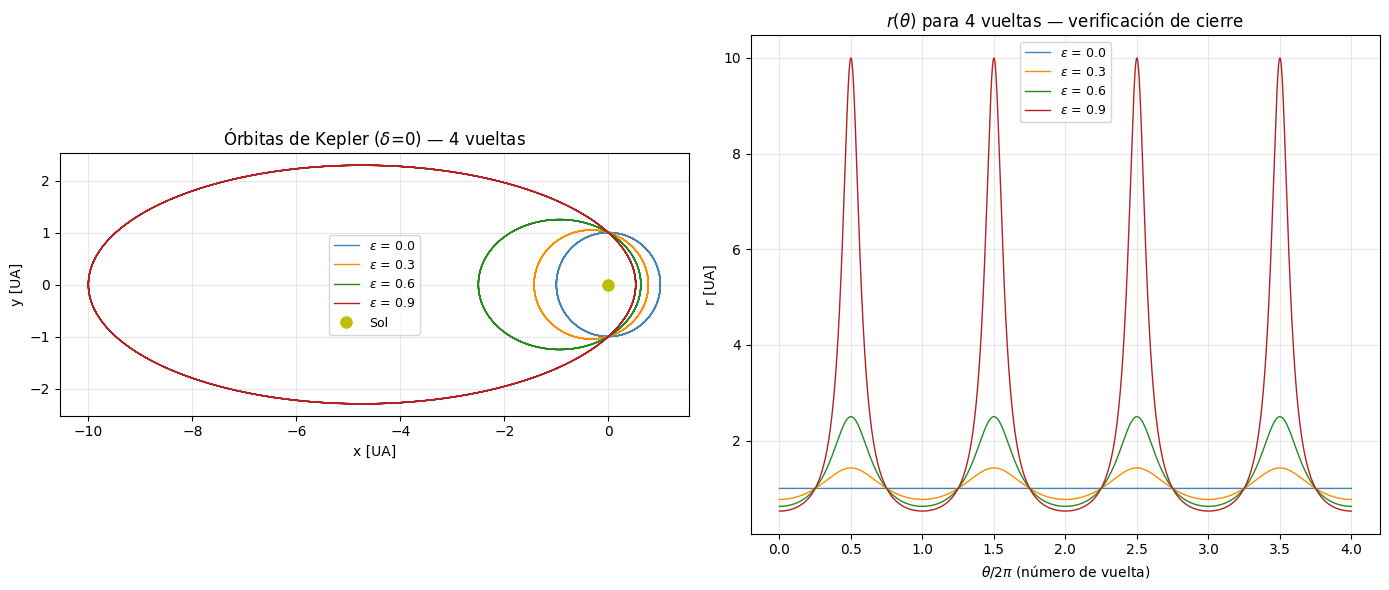

Las 4 vueltas se superponen: las orbitas son exactamente cerradas para delta=0.


In [6]:
alpha = 1.0
delta_kepler = 0.0
theta_max = 4 * 2 * np.pi   # 4 vueltas completas

ti = 0.0
tf = theta_max
nt = 5000
lt = np.linspace(ti, tf, nt)

epsilons = [0.0, 0.3, 0.6, 0.9]
colores  = ['steelblue', 'darkorange', 'forestgreen', 'firebrick']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax  = axes[0]
ax2 = axes[1]

ax.set_aspect(1.0)
ax.set_title(r'Órbitas de Kepler ($\delta$=0) — 4 vueltas')
ax2.set_title(r'$r(\theta)$ para 4 vueltas — verificación de cierre')

for i in range(len(epsilons)):
    eps   = epsilons[i]
    color = colores[i]

    estado_inicial = [(1 + eps) / alpha, 0.0]

    solucion = solve_ivp(derivadas, [ti, tf], estado_inicial,
                         t_eval=lt, args=(alpha, delta_kepler),
                         rtol=1e-9, atol=1e-11)

    thetas = solucion.t
    mu_arr = solucion.y[0]
    r      = 1.0 / mu_arr

    x, y = a_cartesiano(thetas, mu_arr)
    ax.plot(x, y, color=color, lw=1.0, label=r'$\varepsilon$ = ' + str(eps))
    ax2.plot(thetas / (2*np.pi), r, color=color, lw=1.0, label=r'$\varepsilon$ = ' + str(eps))

    mask      = thetas <= 2 * np.pi
    r_exacto  = alpha / (1 + eps * np.cos(thetas[mask]))
    mu_exacto = 1.0 / r_exacto
    error_max = np.max(np.abs(mu_arr[mask] - mu_exacto))
    print('eps =', eps, '  error maximo en mu (primera vuelta):', error_max)

ax.plot(0, 0, 'yo', ms=8, label='Sol', zorder=5)
ax.legend(fontsize=9)
ax.set_xlabel('x [UA]')
ax.set_ylabel('y [UA]')
ax.grid(True, alpha=0.3)

ax2.set_xlabel(r'$\theta / 2\pi$ (número de vuelta)')
ax2.set_ylabel('r [UA]')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'graficos\figura_2_orbitas_cerradas.png', dpi=120, bbox_inches='tight')
plt.show()
print('Las 4 vueltas se superponen: las orbitas son exactamente cerradas para delta=0.')